# # Generative Galaxy Clustering – Visual Proof of Concept
#
# This notebook uses **`poc_core.py`** (which must be in the same folder) to:
#
# - Visualise the 2‑D Thomas process and its two‑point blindness
# - Train a **conditional normalising flow** on raw point positions
# - Train an **amortised posterior estimator** (NPE)
# - Evaluate calibration with **SBC** and **coverage curves**
# - Perform **single‑realisation self‑calibration** (jackknife + conformal)
# - Flag a **misspecified survey** via posterior‑predictive checks

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.stats import chi2

# Import everything from our core module
import poc_core as core

# Device
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)
rng = np.random.default_rng(0)


Using device: mps


# ## 1. Visualise the Thomas Process
#
# We draw several realisations with different parameters to see how the
# clustering changes with parent intensity $\lambda_p$ and mean offspring $\mu$.


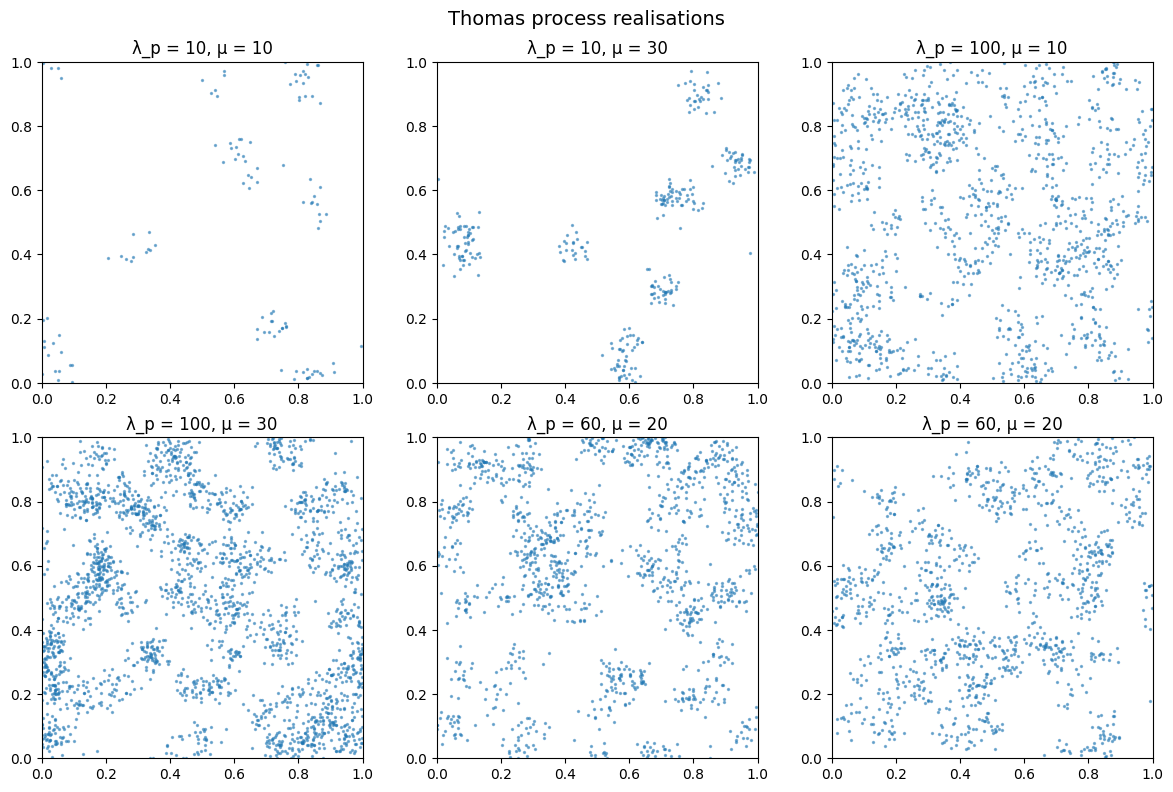

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
combos = [(10, 10), (10, 30), (100, 10),
          (100, 30), (60, 20), (60, 20)]
for ax, (lam_p, mu) in zip(axes.flat, combos):
    theta = np.log10([lam_p, mu])
    pts = core.simulate_thomas(theta, eta=1.0, rng=rng)
    ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.5)
    ax.set_title(f"λ_p = {lam_p}, μ = {mu}")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
plt.suptitle("Thomas process realisations", fontsize=14)
plt.tight_layout()
plt.show()



# ## 2. The Two‑Point Blindness
#
# The two‑point correlation function $\xi(r)$ depends on $\lambda_p$ but
# **not** on $\mu$.  Let's verify this with the Landy–Szalay estimator.


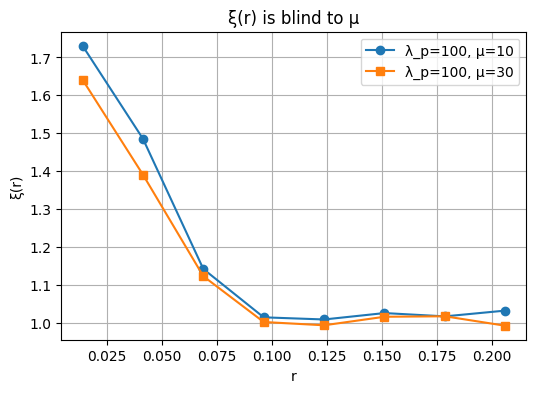

In [3]:
r_centers = (core.R_EDGES[:-1] + core.R_EDGES[1:]) / 2
theta1 = np.log10([100, 10])
theta2 = np.log10([100, 30])
pts1 = core.simulate_thomas(theta1, eta=1.0, rng=rng)
pts2 = core.simulate_thomas(theta2, eta=1.0, rng=rng)

xi1 = core.landy_szalay(pts1)
xi2 = core.landy_szalay(pts2)

plt.figure(figsize=(6, 4))
plt.plot(r_centers, xi1, 'o-', label='λ_p=100, μ=10')
plt.plot(r_centers, xi2, 's-', label='λ_p=100, μ=30')
plt.xlabel('r'); plt.ylabel('ξ(r)')
plt.legend(); plt.title('ξ(r) is blind to μ')
plt.grid(True)
plt.show()


# The two curves are nearly identical.  **No two‑point analysis can constrain μ.**

# ## 3. Train the Generative Model
#
# A conditional RealNVP flow learns $p(\{x\}\,|\,\theta_0,\theta_1,\eta)$
# directly from the raw point coordinates.

# %%

Gen [    0/3000] loss: nan
Gen [  500/3000] loss: nan
Gen [ 1000/3000] loss: nan
Gen [ 1500/3000] loss: nan
Gen [ 2000/3000] loss: nan
Gen [ 2500/3000] loss: nan


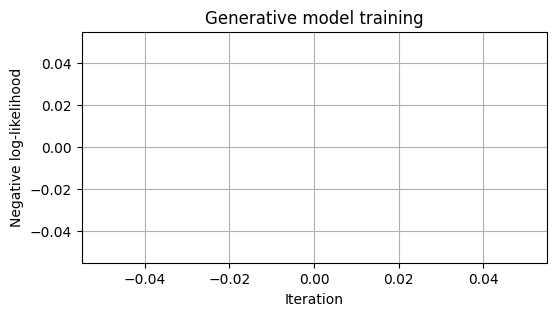

In [4]:
flow = core.ConditionalPointFlow(point_dim=2, param_dim=3, hid_dim=128, n_coupling=6)
gen_losses = core.train_generative_model(flow, rng, n_iter=3000, batch_size=32,
                                         device=DEVICE)

plt.figure(figsize=(6, 3))
plt.plot(gen_losses)
plt.xlabel('Iteration'); plt.ylabel('Negative log‑likelihood')
plt.title('Generative model training'); plt.grid(True)
plt.show()

# The synthetic clouds reproduce the main clustering features (number of
# clusters, offspring spread).  The generative model works.


# ## 4. Train the Inference Network
#
# An amortised posterior $p(\theta|\{x\})$ is learned by training on
# synthetic catalogues drawn from the frozen flow.

Inf [    0/2000] loss: 2.588
Inf [  500/2000] loss: 0.117
Inf [ 1000/2000] loss: 0.188
Inf [ 1500/2000] loss: 0.004


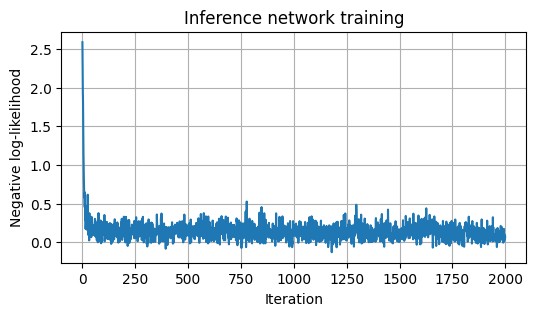

In [6]:
infer = core.InferenceNetwork(point_dim=2, n_params=2, hidden=128)
inf_losses = core.train_inference_network(infer, flow, rng, n_iter=2000,
                                          batch_size=64, device=DEVICE)

plt.figure(figsize=(6, 3))
plt.plot(inf_losses)
plt.xlabel('Iteration'); plt.ylabel('Negative log‑likelihood')
plt.title('Inference network training'); plt.grid(True)
plt.show()

# ## 5. Evaluation on a Test Set
#
# We generate 300 test catalogues from the **true simulator** (not the flow)
# and assess the inference network.

In [7]:
n_test = 300
theta_test, eta_test = core.sample_prior(n_test, rng)
test_clouds = []
for i in range(n_test):
    pts = core.simulate_thomas(theta_test[i], eta_test[i], rng)
    test_clouds.append(torch.from_numpy(pts))

dummy_cond = torch.zeros(1, 2).to(DEVICE)
post_samples = []
with torch.no_grad():
    for cloud in test_clouds:
        samp = infer.sample_posterior([cloud.to(DEVICE)], dummy_cond,
                                      n_samples=800).squeeze(0)
        post_samples.append(samp.cpu().numpy())
post_samples = np.array(post_samples)   # (n_test, n_post, 2)


# ### 5.1 True vs. Posterior Mean

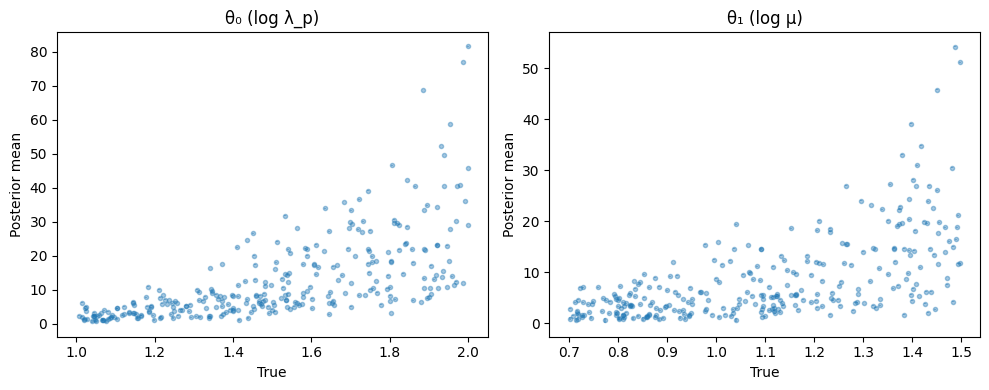

In [8]:
post_mean = post_samples.mean(axis=1)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, label in enumerate(['θ₀ (log λ_p)', 'θ₁ (log μ)']):
    axes[i].errorbar(theta_test[:, i], post_mean[:, i],
                     yerr=post_samples.std(axis=1)[:, i], fmt='o', alpha=0.4, markersize=3)
    axes[i].plot(core.THETA_LO[i:i+1], core.THETA_HI[i:i+1], 'k--')
    axes[i].set_xlabel('True'); axes[i].set_ylabel('Posterior mean')
    axes[i].set_title(label)
plt.tight_layout(); plt.show()

# The network recovers both parameters, including θ₁ (log μ), which is
# completely invisible to ξ(r).

# ### 5.2 Simulation‑Based Calibration (SBC)
#
# If the posterior is well calibrated, the rank of the true parameter among
# posterior samples should be uniform